# Analysis of the simulations

## Functions

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
from cavity_theory import cavity_modes

In [348]:
def plot_cavity_eigenmodes(filepath: str,
                          title: str = None):
    """
    Plot eigenmodes from the simulation.

    Args:
        filepath (str): Path to data

    Returns:
        None
    """
    # Import data
    file = pd.read_csv(filepath)
    n = file.shape[1]
    
    lengths = file.iloc[:, 0].values
    freqs = file.iloc[:, 1:n].values
    
    # Figure
    plt.figure(figsize=(10,6))

    plt.plot(freqs*1e-9, lengths)
    
    plt.ylabel("Length (mm)")
    plt.xlabel("Frequency (GHz)")
    if title is None:
        plt.title("Eigenmodes of the cavity")
    else:
        plt.title(title)
    plt.grid()

    plt.tight_layout()
    plt.show()

In [349]:
def plot_cavity_eigenmodes_colorbar_Q(filepath: str,
                                     title: str = None):
    """
    Plot eigenmodes from the simulation, with a colorbar for the quality factor

    Args:
        filepath (str): Path to data

    Returns:
        None
    """
    # Import data
    file = pd.read_csv(filepath)
    n = file.shape[1]
    
    lengths = file.iloc[:, 0].values
    freqs = file.iloc[:, 1:(n//2+1)].values
    Qs = file.iloc[:, (n//2+1):n].values
    
    n_rows = len(lengths)
    n_modes = n//2
    
    x_freq, y_length, color_Q = [], [], []
    
    for i in range(n_rows):
        for j in range(n_modes):
            x_freq.append(freqs[i,j])
            y_length.append(lengths[i])
            color_Q.append(Qs[i,j])
    
    # Figure
    plt.figure(figsize=(10,7))
    
    scatter = plt.scatter(np.array(x_freq)*1e-9, y_length,
                          c=color_Q, cmap='viridis', s=4,
                          norm=LogNorm(vmin=1e2, vmax=3.3e4))
    cbar = plt.colorbar(scatter)
    cbar.set_label('Quality factor Q')
    
    plt.ylabel("Length (mm)")
    plt.xlabel("Frequency (GHz)")
    if title is None:
        plt.title("Eigenmodes of the cavity")
    else:
        plt.title(title)
    plt.grid()

    plt.tight_layout()
    plt.show()

In [350]:
def plot_cavity_eigenmodes_colorbar_Q_and_theory(filepath: str,
                                                 L_min: float, L_max: float,
                                                 Delta_L: float, R: float,
                                                title: str = None):
    """
    Plot eigenmodes from the simulation, with a colorbar for the quality factor and the theory

    Args:
        filepath (str): Path to data

    Returns:
        None
    """
    # Import data
    file = pd.read_csv(filepath)
    n_shape = file.shape[1]
    
    nb_points = int((L_max - L_min) / Delta_L) + 1
    L_values = np.linspace(L_min, L_max, nb_points)
    
    lengths = file.iloc[:, 0].values
    freqs = file.iloc[:, 1:(n_shape//2+1)].values
    Qs = file.iloc[:, (n_shape//2+1):n_shape].values
    
    n_rows = len(lengths)
    n_modes = n_shape//2
    
    x_freq, y_length, color_Q = [], [], []
    
    for i in range(n_rows):
        for j in range(n_modes):
            x_freq.append(freqs[i,j])
            y_length.append(lengths[i])
            color_Q.append(Qs[i,j])
    
    # Figure
    plt.figure(figsize=(10,7))
    
    # Plot eigenmodes and Q from the simulation
    scatter = plt.scatter(np.array(x_freq)*1e-9, y_length, c=color_Q, cmap='viridis', s=4, norm=LogNorm(vmin=1e2, vmax=3.3e4))
    cbar = plt.colorbar(scatter)
    cbar.set_label('Quality factor Q')
    
    # Plot theory
    for L in L_values:
        for n in range(0, 5):
            for l in range(1, 5):
                # Magnetic mode with m=0
                freq_TM = omega_nlm(n, l, 0, L, R, "TM") / (2 * np.pi)
                if 3.5e9 <= freq_TM <= 8.5e9:
                    plt.scatter(freq_TM*1e-9, L*1e3, color='red', marker='.', s=5)
                    
                    # Plot text of the mode
                    if L == L_values[-1]:
                        plt.text(freq_TM*1e-9 + 0.02, 
                                L*1e3,
                                f"TM{n}{l}0",
                                fontsize=6,
                                color='red',
                                rotation=45)
                        
                # Magnetic and electric mode with m>0
                for m in range(1, 10):
                    freq_TM = omega_nlm(n, l, m, L, R, "TM") / (2 * np.pi)
                    freq_TE = omega_nlm(n, l, m, L, R, "TE") / (2 * np.pi)
                    if 3.5e9 <= freq_TM <= 8.5e9:
                        plt.scatter(freq_TM*1e-9, L*1e3, color='red', marker='.', s=5)
                        
                        if L == L_values[-1]:
                            plt.text(
                                freq_TM*1e-9 + 0.02,
                                L*1e3,
                                f"TM{n}{l}{m}",
                                fontsize=6,
                                color='red',
                                rotation=45
                            )
                    if 3.5e9 <= freq_TE <= 8.5e9:
                        plt.scatter(freq_TE*1e-9, L*1e3, color='blue', marker='.', s=5)
                        
                        if L == L_values[-1]:
                            plt.text(
                                freq_TE*1e-9,
                                L*1e3,
                                f"TE{n}{l}{m}",
                                fontsize=6,
                                color='blue',
                                rotation=45
                            )
    
    plt.ylabel("Length (mm)")
    plt.xlabel("Frequency (GHz)")
    if title is None:
        plt.title("Eigenmodes of the cavity")
    else:
        plt.title(title)
    plt.grid()

    plt.tight_layout()
    plt.show()

In [351]:
def plot_cavity_eigenmodes_and_theory(filepath: str,
                                      L_min: float, L_max: float,
                                      Delta_L: float, R: float,
                                     title: str = None):
    """
    Plot eigenmodes from the simulation, and the theory from Bessel functions

    Args:
        filepath (string): Path to the data
        L_min (float): Minimal length of the cavity
        L_max (float): Maximal length of the cavity
        Delta_L (float): Step between two consecutive values of L
        R (float): Radius of the cavity

    Returns:
        None
    """
    # Import data
    file = pd.read_csv(filepath)
    
    nb_points = int((L_max - L_min) / Delta_L) + 1
    L_values = np.linspace(L_min, L_max, nb_points)
    
    lengths = file.iloc[:, 0]
    freqs = file.iloc[:, 1:file.shape[1]]
    
    # Figure
    plt.figure(figsize=(12,4))
    
    # Plot eigenmodes from the simulation
    plt.plot(freqs*1e-9, lengths, color='k', linewidth=1)
    
    # Plot theory
    for L in L_values:
        for n in range(0, 5):
            for l in range(1, 5):
                
                freq_TM = omega_nlm(n, l, 0, L, R, "TM") / (2 * np.pi)
                if 3.5e9 <= freq_TM <= 8.5e9:
                    plt.scatter(freq_TM*1e-9, L*1e3, color='red', marker='.', s=5)
                        
                    if L == L_values[-1]:
                        plt.text(freq_TM*1e-9 + 0.02, 
                                L*1e3,
                                f"TM{n}{l}0",
                                fontsize=6,
                                color='red',
                                rotation=45)
                    
                for m in range(1, 10):
                    freq_TM = omega_nlm(n, l, m, L, R, "TM") / (2 * np.pi)
                    freq_TE = omega_nlm(n, l, m, L, R, "TE") / (2 * np.pi)
                    if 3.5e9 <= freq_TM <= 8.5e9:
                        plt.scatter(freq_TM*1e-9, L*1e3, color='red', marker='.', s=5)
                        
                        if L == L_values[-1]:
                            plt.text(
                                freq_TM*1e-9 + 0.02,
                                L*1e3,
                                f"TM{n}{l}{m}",
                                fontsize=6,
                                color='red',
                                rotation=45
                            )
                    if 3.5e9 <= freq_TE <= 8.5e9:
                        plt.scatter(freq_TE*1e-9, L*1e3, color='blue', marker='.', s=5)
                        
                        if L == L_values[-1]:
                            plt.text(
                                freq_TE*1e-9,
                                L*1e3,
                                f"TE{n}{l}{m}",
                                fontsize=6,
                                color='blue',
                                rotation=45
                            )
                            
    plt.xlabel("Frequency (GHz)")
    plt.ylabel("L (mm)")
    plt.grid()
    
    # Legend of the figure
    legend_elements = [
    Line2D([0], [0], marker='.', color='w', label='TM',
           markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='.', color='w', label='TE',
           markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='.', color='w', label='Simulation',
           markerfacecolor='black', markersize=8)
    ]

    plt.legend(handles=legend_elements)
    
    if title is None:
        plt.title("Eigenmodes of the cavity")
    else:
        plt.title(title)
    plt.tight_layout()
    plt.show()

In [354]:
def plot_collapse_modes(filepath_pin: str, filepath_cavity: str,
                        L_min: float, L_max: float, 
                        Delta_L: float, R: float,
                       title: str = None):
    """
    Plot eigenmodes and Q-factor from the simulation wrt the length of the pin.

    Args:
        filepath_pin (string): Path to pin data
        filepath_cavity (string): Path to cavity data
        L_min (float): Minimal length of the cavity
        L_max (float): Maximal length of the cavity
        Delta_L (float): Step between two consecutive values of L
        R (float): Radius of the cavity

    Returns:
        None
    """
    # Import data
    file_pin = pd.read_csv(filepath_pin)
    file_cavity = pd.read_csv(filepath_cavity)
    
    nb_points = int((L_max - L_min) / Delta_L) + 1
    L_values = np.linspace(L_min, L_max, nb_points)
    
    plt.figure(figsize=(10,6))
    
    # Define subplots
    ax_freq_cavity = plt.subplot(2, 2, 1)
    ax_Q_cavity = plt.subplot(2, 2, 3)
    ax_freq_pin = plt.subplot(2, 2, 2)
    ax_Q_pin = plt.subplot(2, 2, 4)
    
    # Plot eigenmodes
    for i in range(1, 10):
        ax_freq_cavity.plot(file_cavity.iloc[:, 0][201:251], file_cavity.iloc[:, i][201:251]*1e-9, color='k', linewidth=0.5)
        ax_freq_cavity.set_xlabel("Cavity length (mm)")
        ax_freq_cavity.set_ylabel("Frequency (GHz)")
        ax_freq_cavity.set_ylim(3.5,6)
    
    # Plot theory
    for L in L_values:
        for n in range(0, 5):
            for l in range(1, 5):
                freq_TM = omega_nlm(n, l, 0, L, R, "TM") / (2 * np.pi)
                if 3.5e9 <= freq_TM <= 6e9:
                    ax_freq_cavity.scatter(L*1e3, freq_TM*1e-9, color='red', marker='.', s=3)
                    
                    if L == L_values[-1]:
                        ax_freq_cavity.text(
                            L*1e3,
                            freq_TM*1e-9 + 0.02,
                            f"TM{n}{l}{0}",
                            fontsize=6,
                            color='red',
                            rotation=45
                        )
                for m in range(1, 10):
                    freq_TM = omega_nlm(n, l, m, L, R, "TM") / (2 * np.pi)
                    freq_TE = omega_nlm(n, l, m, L, R, "TE") / (2 * np.pi)
                    if 3.5e9 <= freq_TM <= 6e9:
                        ax_freq_cavity.scatter(L*1e3, freq_TM*1e-9, color='red', marker='.', s=3)
                        if L == L_values[-1]:
                            ax_freq_cavity.text(
                                L*1e3,
                                freq_TM*1e-9 + 0.02,
                                f"TM{n}{l}{m}",
                                fontsize=6,
                                color='red',
                                rotation=45
                            )
                    if 3.5e9 <= freq_TE <= 6e9:
                        ax_freq_cavity.scatter(L*1e3, freq_TE*1e-9, color='blue', marker='.', s=3)
                        if L == L_values[-1]:
                            ax_freq_cavity.text(
                                L*1e3,
                                freq_TE*1e-9 + 0.02,
                                f"TE{n}{l}{m}",
                                fontsize=6,
                                color='blue',
                                rotation=45
                            )
                        
    
    ax_freq_cavity.axvline(105, linestyle='--', color='green')
    
    # Plot eigenmodes with a pin
    for i in range(1, 10):
        ax_freq_pin.plot(-(5 + file_pin.iloc[:, 0]), file_pin.iloc[:, i]*1e-9)
        ax_freq_pin.set_xlabel("Pin length (mm)")
        ax_freq_pin.set_ylabel("Frequency (GHz)")
        ax_freq_pin.set_ylim(3.5,6)
    
    # Plot Q-factor of the cavity
    for j in range(21, 30):
        ax_Q_cavity.plot(file_cavity.iloc[:, 0][201:251], file_cavity.iloc[:, j][201:251])
        ax_Q_cavity.set_xlabel("Cavity length (mm)")
        ax_Q_cavity.set_ylabel("Q")
        ax_Q_cavity.set_ylim(0,26000)
    
    ax_Q_cavity.axvline(105, linestyle='--', color='green')
    
    # Plot Q-factor with a pin
    for j in range(10, 19):
        ax_Q_pin.plot(-(5 + file_pin.iloc[:, 0]), file_pin.iloc[:, j])
        ax_Q_pin.set_xlabel("Pin length (mm)")
        ax_Q_pin.set_ylabel("Q")
        ax_Q_pin.set_ylim(0,26000)
    
    if title is None:
        plt.subtitle("Resonance with a pin")
    else:
        plt.suptitle(title)
    
    plt.tight_layout()
    plt.show()

In [353]:
def plot_S11_3D_and_theory(filepath: str,
                          L_min, L_max,
                          Delta_L, R,
                          dB_min: float = -5,
                          title: str = None):
    """
    Plot the amplitude (in dB) wrt the length of the cavity and the frequency, with the theory.

    Args:
        filepath (string): Path to data
        L_min (float): Minimal length of the cavity
        L_max (float): Maximal length of the cavity
        Delta_L (float): Step between two consecutive values of L
        R (float): Radius of the cavity

    Returns:
        None
    """
    # Import data
    file = pd.read_csv(filepath)
    
    nb_points = int((L_max - L_min) / Delta_L) + 1
    L_values = np.linspace(L_min, L_max, nb_points)

    freqs = file.iloc[:, 0].to_numpy()
    lengths = (file.iloc[:, 1]*10).to_numpy()
    dbs = file.iloc[:, 2].to_numpy()

    freqs_unique = np.sort(np.unique(freqs))
    lengths_unique = np.sort(np.unique(lengths))

    Z = dbs.reshape(len(lengths_unique), len(freqs_unique))
    
    # Figure
    plt.figure(figsize=(12, 6))
    
    # Plot S11
    im = plt.imshow(Z, aspect='auto', origin='lower',
                    extent=[freqs_unique.min(), freqs_unique.max(), lengths_unique.min(), lengths_unique.max()],
                   cmap='inferno', vmin=dB_min)

    cbar = plt.colorbar(im)
    cbar.set_label('dB')
    
    # Plot theory
    for L in L_values:
        for n in range(0, 5):
            for l in range(1, 5):
                
                freq_TM = omega_nlm(n, l, 0, L, R, "TM") / (2 * np.pi)
                if 3.5e9 <= freq_TM <= 8.5e9:
                    plt.scatter(freq_TM*1e-9, L*1e3, color='red', marker='.', s=2)
                        
                    if L == L_values[-1]:
                        plt.text(freq_TM*1e-9 + 0.02, 
                                L*1e3,
                                f"TM{n}{l}0",
                                fontsize=6,
                                color='red',
                                rotation=45)
                    
                for m in range(1, 10):
                    freq_TM = omega_nlm(n, l, m, L, R, "TM") / (2 * np.pi)
                    freq_TE = omega_nlm(n, l, m, L, R, "TE") / (2 * np.pi)
                    if 3.5e9 <= freq_TM <= 8.5e9:
                        plt.scatter(freq_TM*1e-9, L*1e3, color='red', marker='.', s=2)
                        
                        if L == L_values[-1]:
                            plt.text(
                                freq_TM*1e-9 + 0.02,
                                L*1e3,
                                f"TM{n}{l}{m}",
                                fontsize=6,
                                color='red',
                                rotation=45
                            )
                    if 3.5e9 <= freq_TE <= 8.5e9:
                        plt.scatter(freq_TE*1e-9, L*1e3, color='blue', marker='.', s=2)
                        
                        if L == L_values[-1]:
                            plt.text(
                                freq_TE*1e-9,
                                L*1e3,
                                f"TE{n}{l}{m}",
                                fontsize=6,
                                color='blue',
                                rotation=45
                            )

    plt.xlabel('Frequency (GHz)')
    plt.ylabel('Cavity length (mm)')
    if title is None:
        plt.title("$|S_{11}|^2$ (dB)")
    else:
        plt.title(title)

    plt.tight_layout()
    plt.show()

## Results

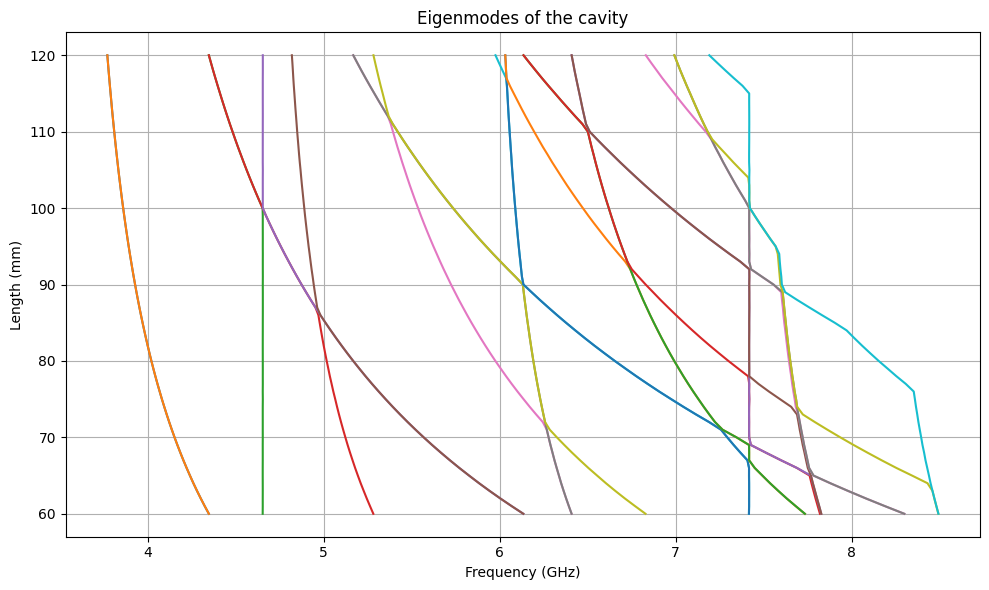

In [246]:
plot_cavity_eigenmodes("Data/20260506_Eigenmods_60-120mm_20modes.csv")

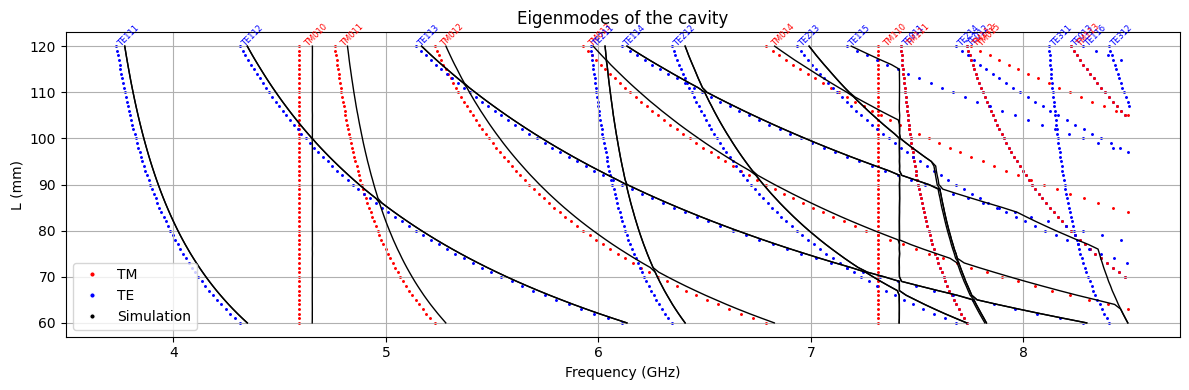

In [250]:
plot_cavity_eigenmodes_and_theory("Data/20260506_Eigenmods_60-120mm_20modes.csv", 
                           L_min = 6e-2, L_max = 12e-2, 
                           Delta_L = 1e-3, 
                           R = 2.5e-2)

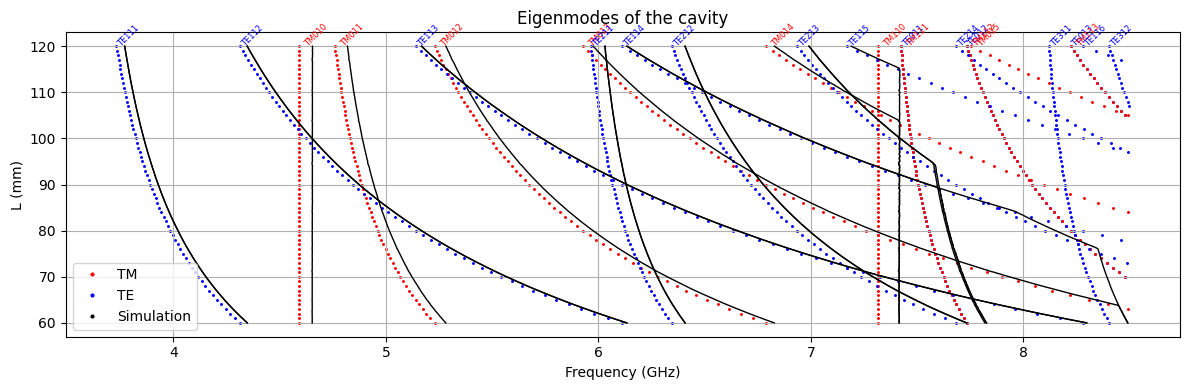

In [251]:
plot_cavity_eigenmodes_and_theory("Data/20260508_Eigenmodes_Cavitylength_60-120mm_20modes.csv", 
                           L_min = 6e-2, L_max = 12e-2, 
                           Delta_L = 1e-3, 
                           R = 25e-3)

Same simulation, but with the right design in ANSYS (substract the two cylinders) and witha  stronger convergence condition (5 passes below 1%)

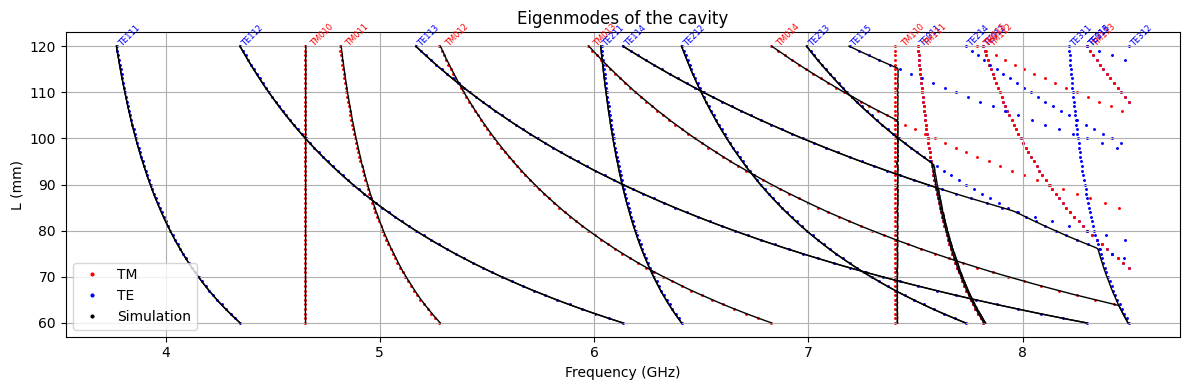

In [252]:
plot_cavity_eigenmodes_and_theory("Data/20260508_Eigenmodes_Cavitylength_60-120mm_20modes.csv", 
                           L_min = 6e-2, L_max = 12e-2, 
                           Delta_L = 1e-3, 
                           R = 24.7e-3)

Simulation : R = 25mm | Theory : R = 24.7mm

Why these 0.3mm: And it's not the skin depth (for Copper at 1GHz --> 2µm) 

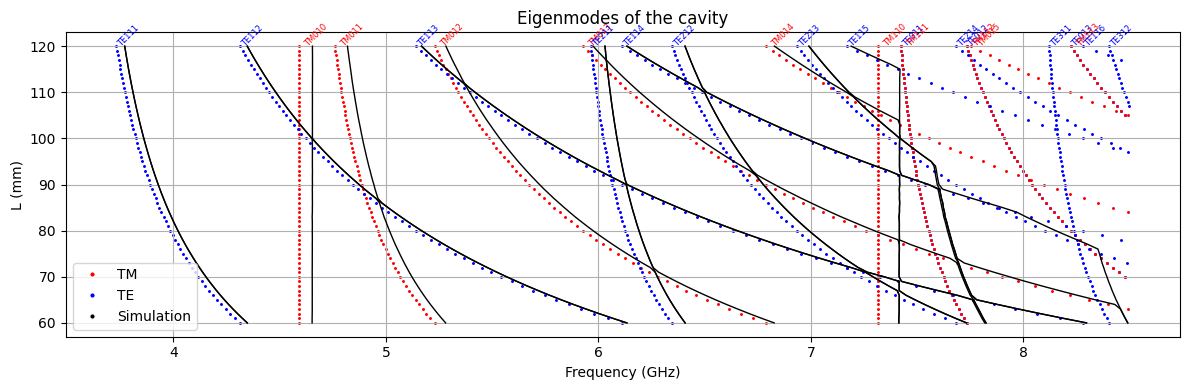

In [253]:
plot_cavity_eigenmodes_and_theory("Data/20260508_Eigenmodes_PECCavitylength_60-120mm_20modes.csv", 
                           L_min = 6e-2, L_max = 12e-2, 
                           Delta_L = 1e-3, 
                           R = 25e-3)

For a perfect cavity (just a vaccum cylinder, and nothing else)

There's still a gap, pretty much the same as with a copper cavity  => **WHY!!!!!!**

Is it from an approximation made by ANSYS ???

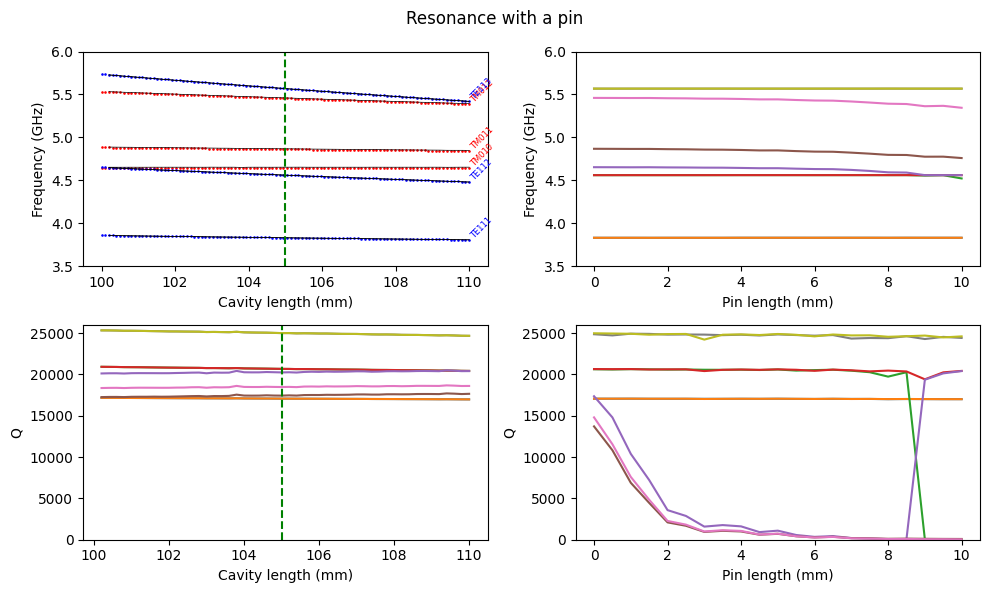

In [254]:
plot_collapse_modes("Data/20260508_Eigenmodes_EigenQ_Pinlength_5-15mm_9modes.csv",
                    "Data/20260508_Eigenmodes_EigenQ_Cavitylength_60-120mm_20modes.csv",
                   L_min = 100e-3, L_max = 110e-3,
                   Delta_L = 1e-4, R = 24.7e-3)

TM modes collapse, and TE modes survive.

First hypothesis : For TM modes : there is a E-field along z : Strong interaction with the pin ???

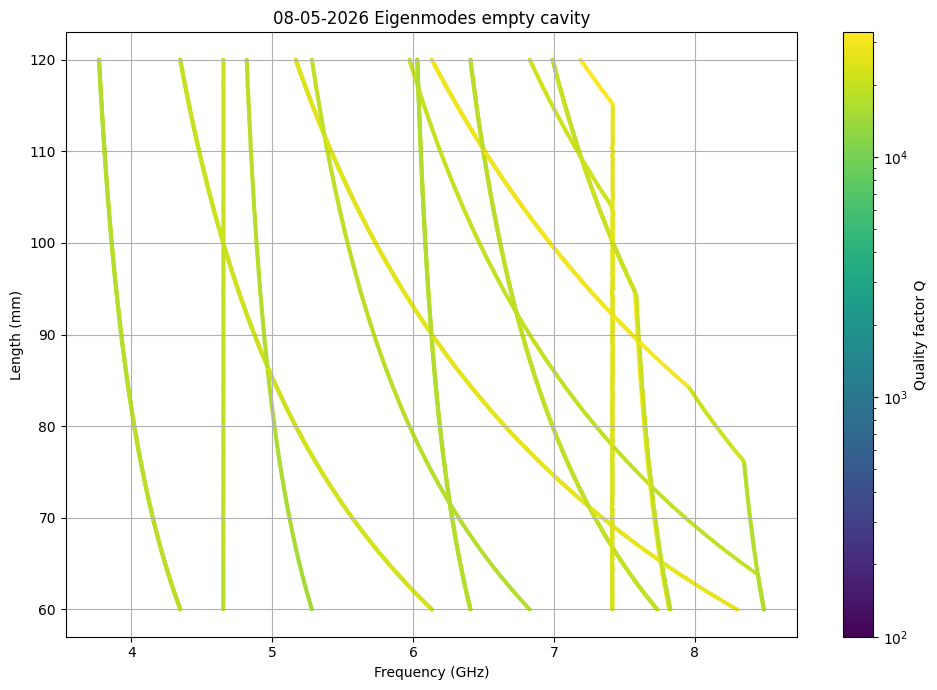

In [364]:
plot_cavity_eigenmodes_colorbar_Q("Data/20260508_Eigenmodes_EigenQ_Cavitylength_60-120mm_20modes.csv",
                                 title="08-05-2026 Eigenmodes empty cavity")

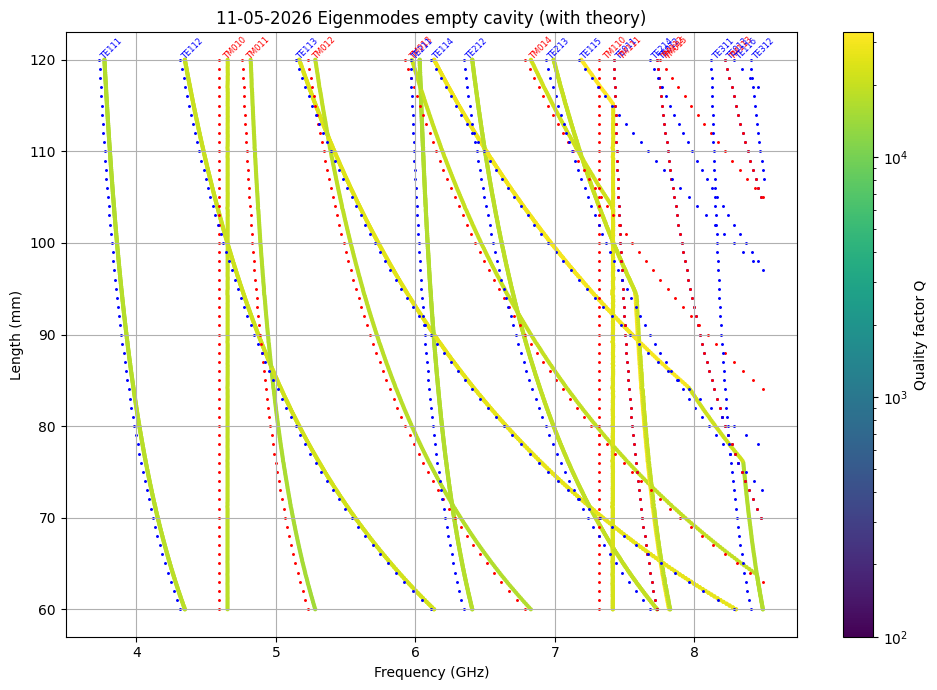

In [363]:
plot_cavity_eigenmodes_colorbar_Q_and_theory("Data/20260508_Eigenmodes_EigenQ_Cavitylength_60-120mm_20modes.csv",
                                            L_min=60e-3, L_max=120e-3,
                                            Delta_L=1e-3, R=25e-3,
                                            title="08-05-2026 Eigenmodes empty cavity (with theory)")

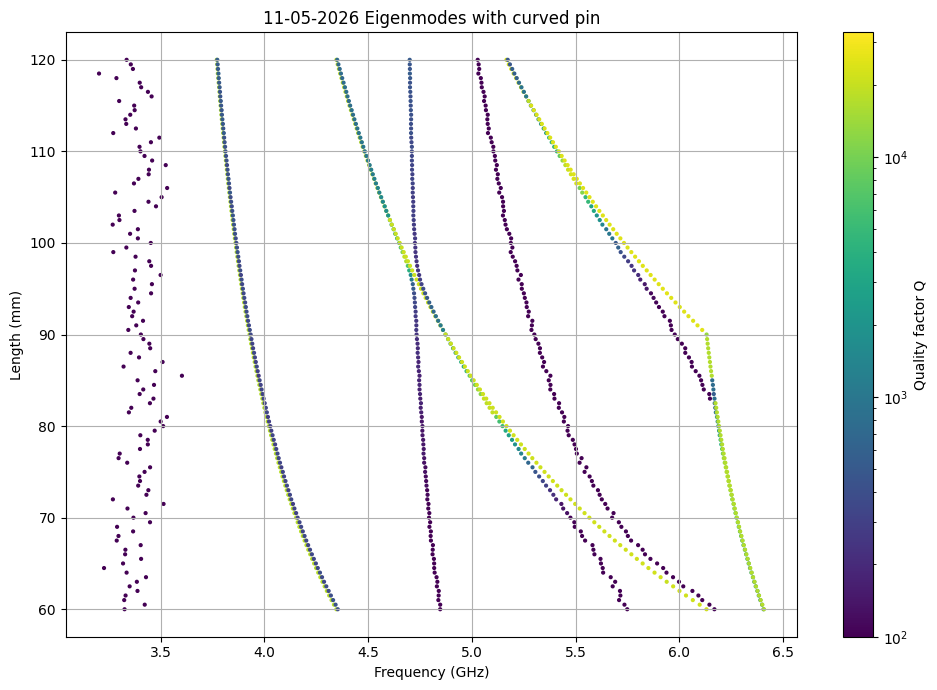

In [362]:
plot_cavity_eigenmodes_colorbar_Q("Data/20260511_Eigenmodes_EigenQ_curvedpin_60-120mm_9modes.csv",
                                 title="11-05-2026 Eigenmodes with curved pin")

Same thing, but with a curved pin, but only with the first 9 modes (Simulation takes too much time)

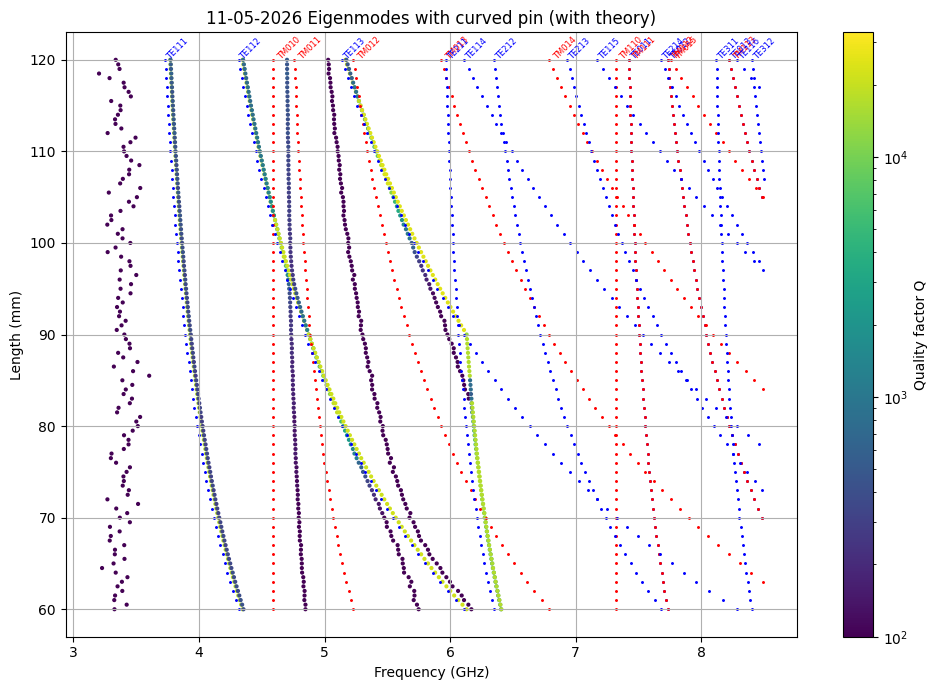

In [361]:
plot_cavity_eigenmodes_colorbar_Q_and_theory("Data/20260511_Eigenmodes_EigenQ_curvedpin_60-120mm_9modes.csv",
                                            L_min=60e-3, L_max=120e-3,
                                            Delta_L=1e-3, R=25e-3,
                                            title="11-05-2026 Eigenmodes with curved pin (with theory)")

The first TE mode looks like bad, but there is a degeneration: There is a very good one (high Q) behind it.

--> TM modes move and have a really low Q factor

--> TE modes don't move, and keep a good Q

=> Conclusion: We should excitate TE modes and our cavity (There's a high proba that wa can't excitate TM modes, are a least it's very difficult and not optimal)

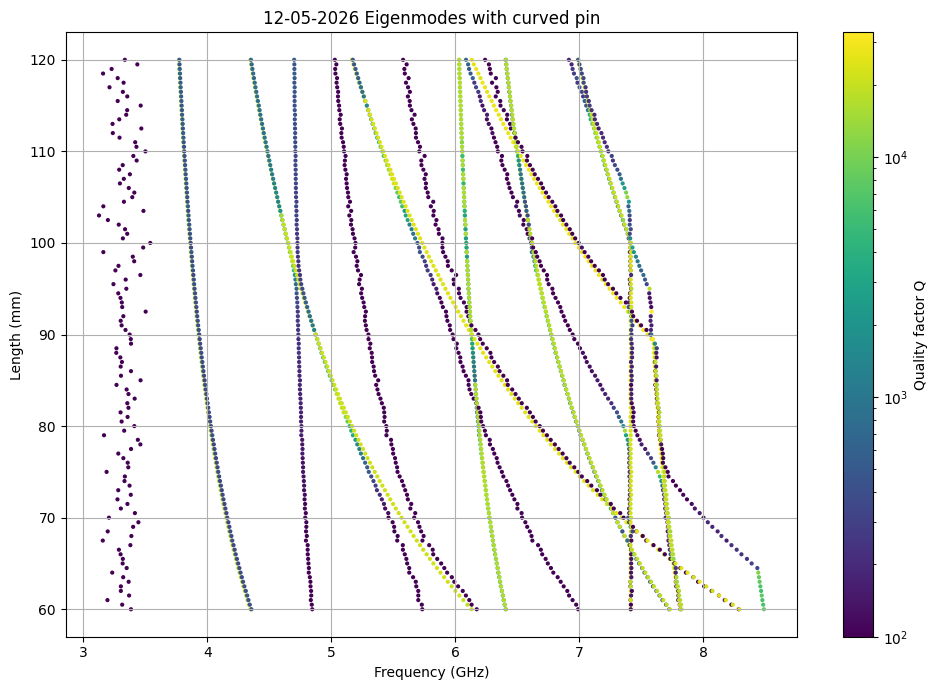

In [360]:
plot_cavity_eigenmodes_colorbar_Q("Data/20260512_Eigenmodes_EigenQ_curvedpin_60-120mm_20modes.csv",
                                 title="12-05-2026 Eigenmodes with curved pin")

Looking at the structure of the electric field :
- For TE modes, E-field forms entire circle in the cavity -> The field is weak near the pin
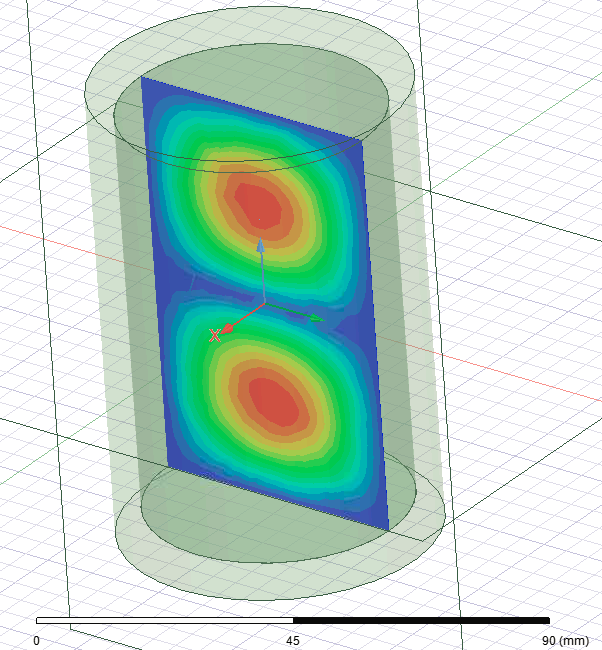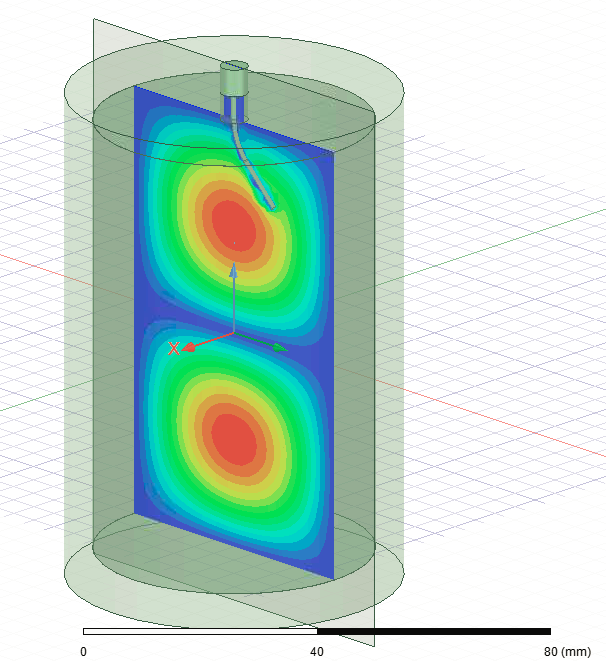
E-field TE112 (Cavity length=80mm)
- For TM modes, E-field forms half-circle on the boundaries -> The filed is strong near the pin
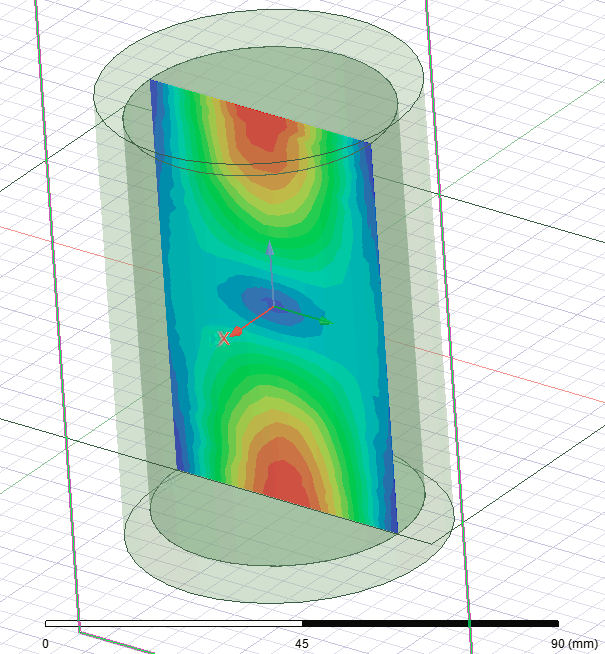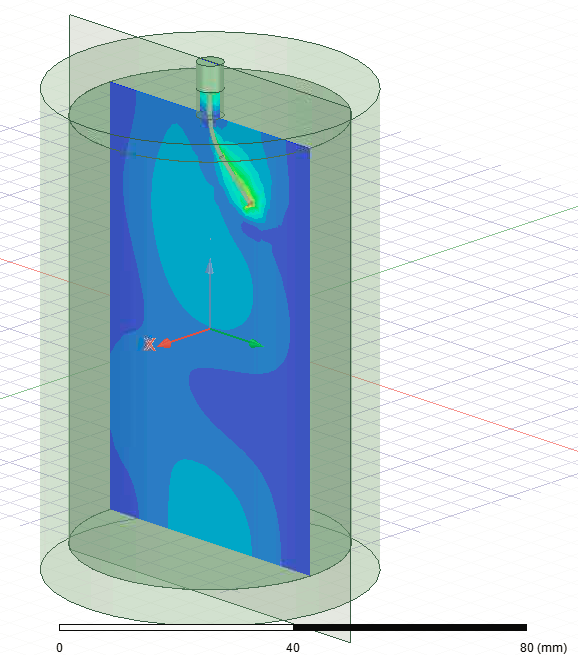
E-field TM011 (Cavity length=80mm)
=> This explains why TM modes are highly influenced by the presence of the pin

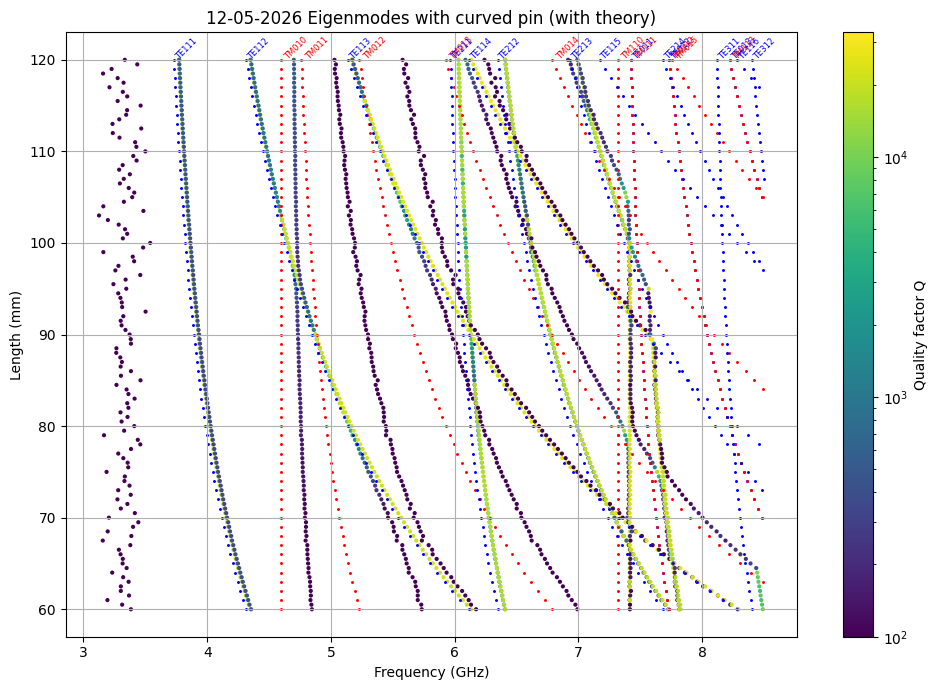

In [358]:
plot_cavity_eigenmodes_colorbar_Q_and_theory("Data/20260512_Eigenmodes_EigenQ_curvedpin_60-120mm_20modes.csv",
                                            L_min=60e-3, L_max=120e-3,
                                            Delta_L=1e-3, R=25e-3,
                                            title="12-05-2026 Eigenmodes with curved pin (with theory)")

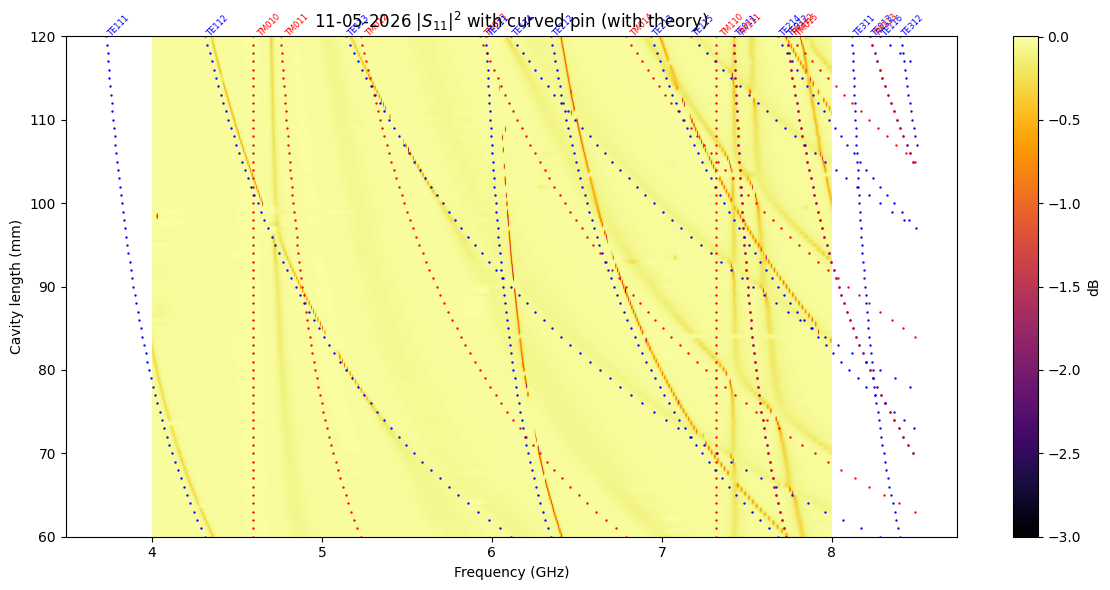

In [359]:
plot_S11_3D_and_theory("Data/20260511_S11_4-8GHz_3Dplot.csv",
                      L_min=60e-3, L_max=120e-3,
                      Delta_L=1e-3, R=25e-3,
                      dB_min=-3,
                      title="11-05-2026 $|S_{11}|^2$ with curved pin (with theory)")

# Report figures

In [3]:
base_folder = base_folder = '/home/jovyan/steelelab/simulation_data/Asuscube5/Pacome/'

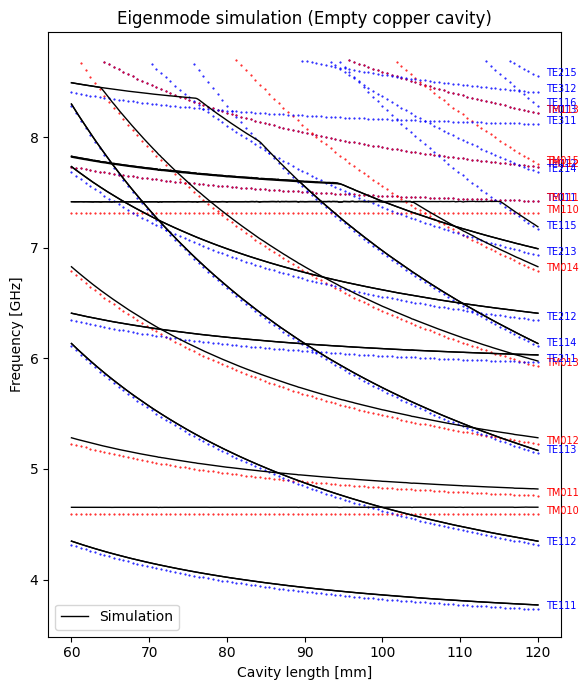

In [28]:
from matplotlib.lines import Line2D

filename = '20260508_Eigenmodes_Cavitylength.csv'
filepath = base_folder + filename

thmodes = cavity_modes(radius = 25, # mm
                       lengths = np.linspace(60, 120, 100), # mm
                       freq_window = (3.5, 8.7) # GHz
                       )

thmodes.compute_modes()

file = pd.read_csv(filepath)

lengths = file.iloc[:, 0]
freqs = file.iloc[:, 1:file.shape[1]]

# Figure
plt.figure(figsize=(6,7))
#plt.plot(lengths, freqs*1e-9, color='k', linewidth=1)
plt.plot(lengths, freqs*1e-9, color='k', linewidth=1)
thmodes.plot_modes(crossing=None, inverted_axis = False)
plt.xlabel('Cavity length [mm]')
plt.ylabel('Frequency [GHz]')

legend_elements = [
    Line2D([0], [0], color='k', lw=1, label='Simulation'),
]

plt.legend(handles=legend_elements, loc='lower left')
plt.title('Eigenmode simulation (Empty copper cavity)')
plt.tight_layout()
plt.savefig('Cavity_map_simulation_eigenmodes.png')
plt.show()